In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

BASE_DIR = os.path.join("results", "email")

def parse_benchmark_times(base_dir):
    records = []
    for d in sorted(os.listdir(base_dir)):
        full_path = os.path.join(base_dir, d)
        # Filtra solo le cartelle di benchmark valide escludendo oldscript
        if not os.path.isdir(full_path) or not (d.startswith("LPA_") or d.startswith("PAPER_")):
            continue
        
        parts = d.split("_")
        prefix = parts[0]
        variant = parts[1]
        cores_str = parts[2]
        if not cores_str.startswith("local"):
            continue
        cores = int(cores_str.replace("local", ""))

        time_file = os.path.join(full_path, "gf_benchmark_times.txt" if "GF" in d else "benchmark_times.txt")
        if os.path.exists(time_file):
            with open(time_file) as f:
                for line in f:
                    line = line.strip()
                    if not line or "," not in line:
                        continue
                    name, t = line.split(",", 1)
                    if prefix == "LPA":
                        algo_label = "GraphFrames (LPA)" if variant == "GF" else "Ours RDD (LPA)"
                    else:
                        algo_label = f"Paper ({name})"
                    
                    records.append({
                        "algo": algo_label,
                        "cores": cores,
                        "time": float(t),
                        "dir_name": d
                    })
                    
    return pd.DataFrame(records).sort_values(by=["algo", "cores"])

def read_spark_csv(dir_path):
    files = glob.glob(os.path.join(dir_path, "part-[0-9]*"))
    if not files:
        return pd.DataFrame(columns=["node", "comm"])
    df = pd.concat([pd.read_csv(f, header=None, names=["node", "comm"]) for f in files])
    return df.drop_duplicates(subset=["node"]).sort_values("node")

def read_full_ground_truth(gt_dir):
    files = glob.glob(os.path.join(gt_dir, "part-[0-9]*"))
    if not files:
        return pd.DataFrame(columns=["node", "comm"])
    return pd.concat([pd.read_csv(f, header=None, names=["node", "comm"]) for f in files])

def compute_avg_f1(df_res, df_gt_all):
    if df_gt_all.empty or df_res.empty:
        return 0.0

    gt_clusters = df_gt_all.groupby("comm")["node"].apply(set).to_dict()
    pred_map = dict(zip(df_res["node"], df_res["comm"]))
    pred_sizes = df_res["comm"].value_counts().to_dict()

    f1_scores = []
    for _, gt_nodes in gt_clusters.items():
        if not gt_nodes:
            continue

        candidate_counts = Counter(pred_map[u] for u in gt_nodes if u in pred_map)
        if not candidate_counts:
            f1_scores.append(0.0)
            continue

        len_gt = len(gt_nodes)
        best_f1 = max(
            (2.0 * intersection) / (len_gt + pred_sizes[c])
            for c, intersection in candidate_counts.items()
        )
        f1_scores.append(best_f1)

    return sum(f1_scores) / len(f1_scores) if f1_scores else 0.0

=== EXECUTION TIME (seconds) ===
             algo  cores      time
LPA (GraphFrames)      2    3.4207
LPA (GraphFrames)      4    3.0643
LPA (GraphFrames)      8    3.3620
       LPA (ours)      2 2524.1177
       LPA (ours)      4 1259.4513
       LPA (ours)      8  632.7556
        3-Cliques      2  282.5389
        3-Cliques      4  282.1217
        3-Cliques      8  281.5687
       FastGreedy      2  187.1975
       FastGreedy      4  184.2876
       FastGreedy      8  174.6508
          Louvain      2  871.8864
          Louvain      4  839.3879
          Louvain      8  771.7885


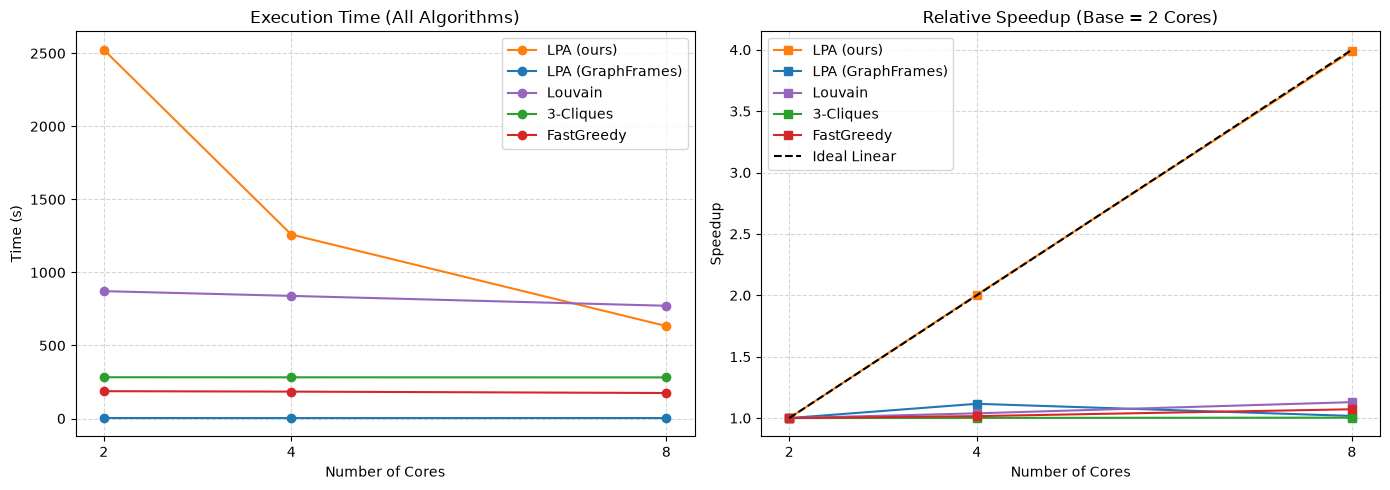

In [6]:
df_bench = parse_benchmark_times(BASE_DIR)

import matplotlib.pyplot as plt

# Mappatura dei possibili nomi grezzi nei nomi della tabella
name_mapping = {
    "Ours RDD (LPA)": "LPA (ours)",
    "GraphFrames (LPA)": "LPA (GraphFrames)",
    "LPA (Graphframes)": "LPA (GraphFrames)",
    "Paper (Louvain_gamma_1)": "Louvain",
    "Paper (Louvain)": "Louvain",
    "Paper (3-Cliques)": "3-Cliques",
    "Paper (FastGreedy)": "FastGreedy",
    "Paper (Fastgreedy)": "FastGreedy",
    "Fastgreedy": "FastGreedy",
}

# Associazione colori coerente con la distribuzione delle dimensioni
algo_colors = {
    "LPA (GraphFrames)": "tab:blue",
    "LPA (ours)": "tab:orange",
    "Louvain": "tab:purple",
    "3-Cliques": "tab:green",
    "FastGreedy": "tab:red",
}

# Ordine di visualizzazione come da tabella
algo_order = [
    "LPA (ours)",
    "LPA (GraphFrames)",
    "Louvain",
    "3-Cliques",
    "FastGreedy",
]

df_bench["algo"] = df_bench["algo"].replace(name_mapping)

print("=== EXECUTION TIME (seconds) ===")
print(df_bench[["algo", "cores", "time"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for algo in algo_order:
    group = df_bench[df_bench["algo"] == algo].sort_values("cores")
    if group.empty:
        continue

    base_series = group[group["cores"] == 2]["time"]
    if base_series.empty:
        continue
    base_time = base_series.values[0]

    color = algo_colors.get(algo)

    # Plot tempi lineari
    axes[0].plot(group["cores"], group["time"], marker="o", color=color, label=algo)

    # Calcolo e plot speedup
    speedup = base_time / group["time"]
    axes[1].plot(group["cores"], speedup, marker="s", color=color, label=algo)

axes[0].set_title("Execution Time (All Algorithms)")
axes[0].set_xlabel("Number of Cores")
axes[0].set_ylabel("Time (s)")
axes[0].set_xticks([2, 4, 8])
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

# Curva ideale lineare normalizzata a 2 core
ideal_cores = [2, 4, 8]
ideal_speedup = [c / 2 for c in ideal_cores]
axes[1].plot(ideal_cores, ideal_speedup, "k--", label="Ideal Linear")

axes[1].set_title("Relative Speedup (Base = 2 Cores)")
axes[1].set_xlabel("Number of Cores")
axes[1].set_ylabel("Speedup")
axes[1].set_xticks(ideal_cores)
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend()

plt.tight_layout()
fig.savefig("email_time_results.pdf", bbox_inches="tight")
plt.show()

In [4]:
# Definizione dei target di valutazione da analizzare (usando come riferimento le cartelle a 2 core)
eval_targets = [
    ("LPA_GF_local2_8g", "results_lpa_gf", "gt_mapped_gf", "GraphFrames (LPA)"),
    ("LPA_OURS_local2_8g", "results_lpa", "gt_mapped", "Ours RDD (LPA)"),
    ("PAPER_GF_local2_8g", "results_3_cliques", "gt_mapped_gf", "Paper (3-Cliques)"),
    ("PAPER_GF_local2_8g", "results_fastgreedy", "gt_mapped_gf", "Paper (FastGreedy)"),
    ("PAPER_GF_local2_8g", "results_louvain_gamma_1", "gt_mapped_gf", "Paper (Louvain)"),
]

# Carica la GT completa una sola volta da LPA_OURS
gt_base_path = os.path.join(BASE_DIR, "LPA_OURS_local2_8g", "gt_mapped")
df_gt_all = read_full_ground_truth(gt_base_path)
df_gt_disjoint = df_gt_all.drop_duplicates(subset=["node"]).sort_values("node")

qual_records = []
cached_dfs = {"gt_all": df_gt_all}

for dir_name, subfolder, _, label in eval_targets:
    target_path = os.path.join(BASE_DIR, dir_name, subfolder)
    if not os.path.exists(target_path):
        continue

    df_res = read_spark_csv(target_path)
    cached_dfs[label] = df_res

    # 1. Metrica Overlapping SNAP
    avg_f1 = compute_avg_f1(df_res, df_gt_all)

    # 2. Metriche Disgiunte
    merged = pd.merge(df_res, df_gt_disjoint, on="node", suffixes=("_pred", "_gt"))
    nmi = normalized_mutual_info_score(merged["comm_gt"], merged["comm_pred"]) if not merged.empty else 0.0
    ari = adjusted_rand_score(merged["comm_gt"], merged["comm_pred"]) if not merged.empty else 0.0

    # 3. Metriche di distribuzione
    comm_counts = df_res["comm"].value_counts()
    num_comms = len(comm_counts)
    max_size = comm_counts.iloc[0] if not comm_counts.empty else 0
    median_size = comm_counts.median() if not comm_counts.empty else 0
    singletons_pct = (comm_counts == 1).mean() * 100 if not comm_counts.empty else 0.0

    qual_records.append({
        "Algorithm": label,
        "Avg F1": round(avg_f1, 4),
        "NMI": round(nmi, 4),
        "ARI": round(ari, 4),
        "Num Comms": num_comms,
        "Median Size": int(median_size),
        "Max Size": max_size,
        "Singletons (%)": round(singletons_pct, 2),
        "Evaluated Nodes (GT)": len(merged)
    })

df_qual = pd.DataFrame(qual_records)
print("=== CLUSTERING QUALITY ===")
print(df_qual.to_string(index=False))

=== CLUSTERING QUALITY ===
         Algorithm  Avg F1    NMI    ARI  Num Comms  Median Size  Max Size  Singletons (%)  Evaluated Nodes (GT)
 GraphFrames (LPA)  0.0610 0.0869 0.0008          4           27       930            25.0                   986
    Ours RDD (LPA)  0.1095 0.2433 0.0286          4           81       806             0.0                   986
 Paper (3-Cliques)  0.0453 0.0000 0.0000          1          875       875             0.0                   875
Paper (FastGreedy)  0.2941 0.5791 0.3436         21           16       197             0.0                   986
   Paper (Louvain)  0.4207 0.6980 0.5241         32           28       108             0.0                   986


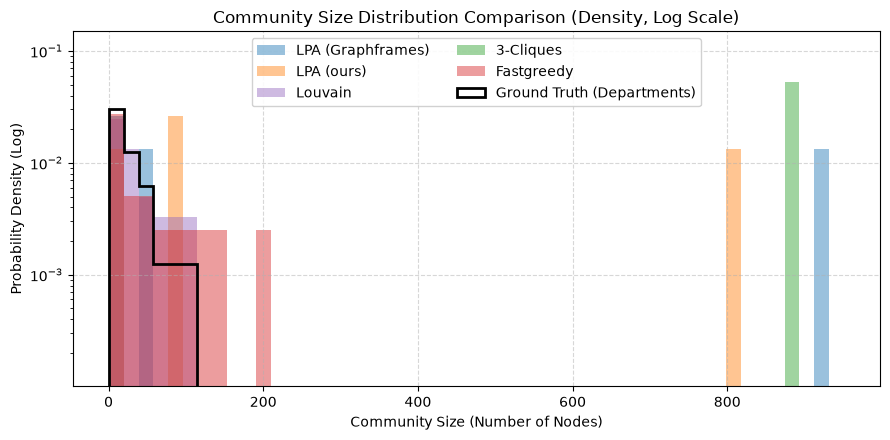

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Helper per recuperare la serie delle dimensioni indipendentemente dalla chiave esatta
def get_comm_sizes(*keys):
    for k in keys:
        if k in cached_dfs:
            df = cached_dfs[k]
            col = "comm" if "comm" in df.columns else "community"
            return df[col].value_counts()
    return None

methods = [
    {"label": "LPA (Graphframes)", "sizes": get_comm_sizes("LPA (Graphframes)", "GraphFrames (LPA)"), "color": "tab:blue", "alpha": 0.45},
    {"label": "LPA (ours)", "sizes": get_comm_sizes("LPA (ours)", "Ours RDD (LPA)"), "color": "tab:orange", "alpha": 0.45},
    {"label": "Louvain", "sizes": get_comm_sizes("Louvain", "Paper (Louvain)", "Paper (Louvain_gamma_1)"), "color": "tab:purple", "alpha": 0.45},
    {"label": "3-Cliques", "sizes": get_comm_sizes("3-Cliques", "Paper (3-Cliques)"), "color": "tab:green", "alpha": 0.45},
    {"label": "Fastgreedy", "sizes": get_comm_sizes("Fastgreedy", "Paper (Fastgreedy)", "Paper (FastGreedy)"), "color": "tab:red", "alpha": 0.45},
]

sizes_gt = cached_dfs["gt_all"].groupby("comm").size() if "gt_all" in cached_dfs else None

fig, ax = plt.subplots(figsize=(9, 4.5))

bins = 50
bin_range = (1, 950)

for m in methods:
    if m["sizes"] is not None and len(m["sizes"]) > 0:
        ax.hist(
            m["sizes"],
            bins=bins,
            range=bin_range,
            density=True,
            log=True,
            alpha=m["alpha"],
            color=m["color"],
            label=m["label"]
        )

if sizes_gt is not None:
    ax.hist(
        sizes_gt,
        bins=bins,
        range=bin_range,
        density=True,
        log=True,
        histtype="step",
        linewidth=2,
        color="black",
        label="Ground Truth (Departments)"
    )

ax.set_title("Community Size Distribution Comparison (Density, Log Scale)")
ax.set_xlabel("Community Size (Number of Nodes)")
ax.set_ylabel("Probability Density (Log)")
ax.grid(True, linestyle="--", alpha=0.5)

# Limite inferiore a 10^-4 e superiore sopra 10^-1 per uniformarlo ad Amazon
ax.set_ylim(1e-4, 1.5e-1)
ax.set_yticks([ 1e-3, 1e-2, 1e-1])

# 2. Legenda centrata in alto su 2 colonne nello spazio vuoto centrale
ax.legend(loc="upper center", ncol=2, framealpha=0.9)

plt.tight_layout()
fig.savefig("email_distribuition_results.pdf", bbox_inches="tight")
plt.show()